In [8]:
!pip install gradio --quiet

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import gradio as gr
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
IMG_SIZE    = (300, 300)
BATCH_SIZE  = 32
EPOCHS_HEAD = 15
EPOCHS_FINE = 30
NUM_CLASSES = 4
DATA_DIR    = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"  # ✅ Fixed
MODEL_PATH  = "/kaggle/working/best_model.keras"

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print("Classes:", CLASS_NAMES)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [18]:
def build_model():
    base_model = EfficientNetB3(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.6),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model, base_model

model, base_model = build_model()
model.summary()

I0000 00:00:1772272292.826208      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,216,563 (42.79 MB)

 Trainable params: 429,956 (1.64 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, verbose=1)
]

print("\n📍 Phase 1: Training the classification head...")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


📍 Phase 1: Training the classification head...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1772272323.990397     261 service.cc:152] XLA service 0x7a4c74219c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772272323.990435     261 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772272327.650483     261 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772272346.742337     261 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.3315 - loss: 2.2670
Epoch 1: val_loss improved from inf to 1.90591, saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 175s 970ms/step - accuracy: 0.3316 - loss: 2.2662 - val_accuracy: 0.3839 - val_loss: 1.9059 - learning_rate: 5.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.3639 - loss: 1.9797
Epoch 2: val_loss improved from 1.90591 to 1.84447, saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 106s 760ms/step - accuracy: 0.3640 - loss: 1.9796 - val_accuracy: 0.5089 - val_loss: 1.8445 - learning_rate: 5.0000e-04
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.3752 - loss: 1.8941
Epoch 3: val_loss improved from 1.84447 to 1.79458, saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 107s 766ms/step - accuracy: 0.3752 - loss: 1.8940 - val_accuracy: 0.5339 - val_loss: 1.7946 - learning_rate: 5.0000e-04
E

In [20]:
base_model.trainable = True

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(MODEL_PATH, save_best_only=True, verbose=1)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n📍 Phase 2: Fine-tuning the full network...")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)


📍 Phase 2: Fine-tuning the full network...
Epoch 1/30


2026-02-28 10:21:57.070695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 10:21:57.271979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 10:21:57.917642: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 10:21:58.135634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-28 10:21:58.571748: E external/local_xla/xla/stream_

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.3319 - loss: 1.6082
Epoch 1: val_loss improved from inf to 1.61712, saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 243s 881ms/step - accuracy: 0.3325 - loss: 1.6074 - val_accuracy: 0.3277 - val_loss: 1.6171 - learning_rate: 1.0000e-05
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.5470 - loss: 1.2967
Epoch 2: val_loss improved from 1.61712 to 1.52914, saving model to /kaggle/working/best_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 115s 817ms/step - accuracy: 0.5472 - loss: 1.2965 - val_accuracy: 0.4187 - val_loss: 1.5291 - learning_rate: 1.0000e-05
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.6153 - loss: 1.1824
Epoch 3: val_loss did not improve from 1.52914
140/140 ━━━━━━━━━━━━━━━━━━━━ 111s 787ms/step - accuracy: 0.6154 - loss: 1.1823 - val_accuracy: 0.3161 - val_loss: 1.5525 - learning_rate: 1.0000e-05
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 751ms/step -

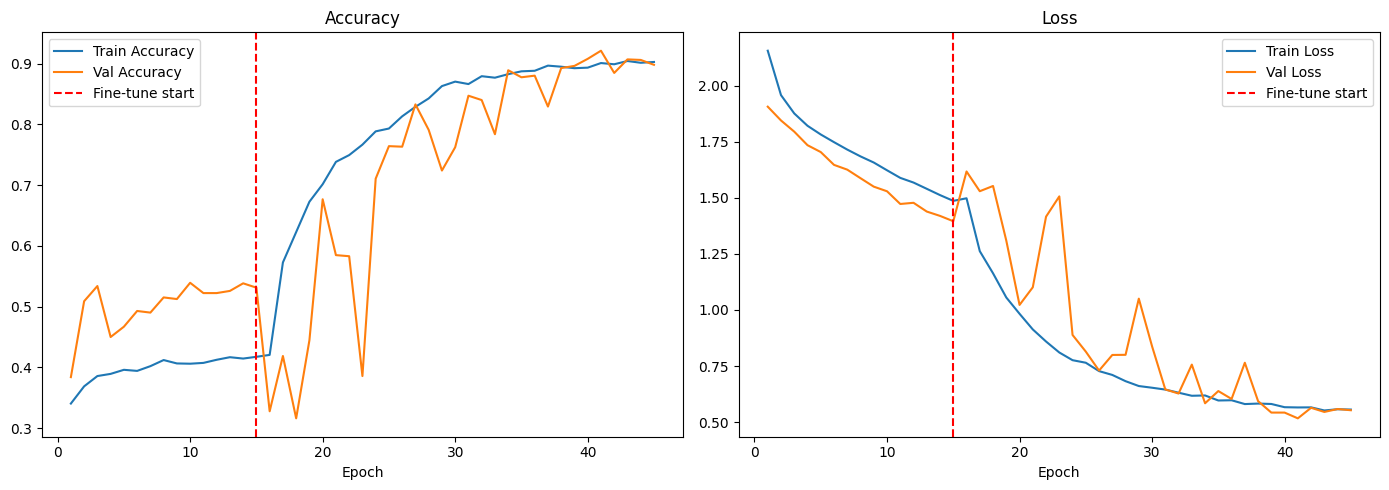

In [21]:
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']

    epochs = range(1, len(acc) + 1)
    phase_split = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, train, val, title in zip(
        axes, [acc, loss], [val_acc, val_loss], ["Accuracy", "Loss"]
    ):
        ax.plot(epochs, train, label=f"Train {title}")
        ax.plot(epochs, val,   label=f"Val {title}")
        ax.axvline(phase_split, color='red', linestyle='--', label="Fine-tune start")
        ax.set_title(title)
        ax.legend()
        ax.set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_history.png", dpi=150)
    plt.show()

plot_history(history1, history2)


📊 Evaluating on test set...
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 302ms/step - accuracy: 0.8314 - loss: 0.7825

Test Accuracy: 89.31%
Test Loss:     0.6214
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      glioma       0.85      0.80      0.82       400
  meningioma       0.85      0.83      0.84       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.96      0.95      0.96       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



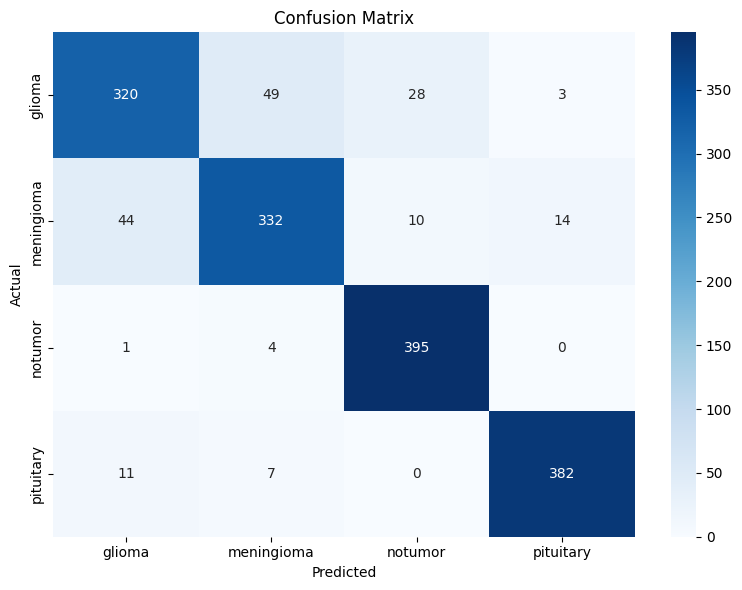

In [22]:
model = tf.keras.models.load_model(MODEL_PATH)

print("\n📊 Evaluating on test set...")
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

# ✅ FIXED Grad-CAM — properly routes through base model's graph
def make_gradcam_heatmap(img_array, model):
    base = model.layers[0]  # EfficientNetB3 submodel
    last_conv_layer = base.get_layer("top_conv")

    grad_model = tf.keras.Model(
        inputs=base.input,
        outputs=[last_conv_layer.output, base.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, _ = grad_model(img_array)
        predictions = model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), CLASS_NAMES[pred_index.numpy()], predictions[0].numpy()

def overlay_gradcam(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)
    heatmap, pred_class, probs = make_gradcam_heatmap(img_array_expanded, model)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    original = np.uint8(255 * img_array)
    superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original);     axes[0].set_title("Original MRI");  axes[0].axis('off')
    axes[1].imshow(superimposed); axes[1].set_title("Grad-CAM");       axes[1].axis('off')
    plt.suptitle(f"Prediction: {pred_class} ({np.max(probs)*100:.1f}% confidence)", fontsize=13)
    plt.tight_layout()
    plt.show()
    return pred_class, probs

In [24]:
def diagnose(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(tf.keras.utils.img_to_array(img) / 255.0, axis=0)
    probs = model.predict(img_array, verbose=0)[0]
    confidence = np.max(probs) * 100
    predicted_class = CLASS_NAMES[np.argmax(probs)]

    if confidence < 70:
        result = "⚠️ Inconclusive — recommend specialist review"
    else:
        result = predicted_class.upper()

    print(f"\n🧠 Diagnosis:   {result}")
    print(f"   Confidence:  {confidence:.1f}%\n")
    for cls, prob in zip(CLASS_NAMES, probs):
        bar = "█" * int(prob * 30)
        print(f"   {cls:<15} {prob*100:5.1f}%  {bar}")

    return result, confidence

In [25]:
def gradio_predict(image):
    temp_path = "/kaggle/working/temp_input.jpg"
    cv2.imwrite(temp_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

    img_array = np.expand_dims(
        tf.keras.utils.img_to_array(
            tf.keras.utils.load_img(temp_path, target_size=IMG_SIZE)
        ) / 255.0,
        axis=0
    )

    probs = model.predict(img_array, verbose=0)[0]
    confidence = float(np.max(probs)) * 100
    predicted_class = CLASS_NAMES[np.argmax(probs)]

    if confidence < 70:
        label = "⚠️ Inconclusive — recommend specialist review"
    else:
        label = predicted_class.replace("_", " ").title()

    result_dict = {cls.replace("_", " ").title(): float(p) for cls, p in zip(CLASS_NAMES, probs)}
    summary = f"**Diagnosis:** {label}\n\n**Confidence:** {confidence:.1f}%"

    return result_dict, summary


demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(label="Upload MRI Scan"),
    outputs=[
        gr.Label(label="Class Probabilities"),
        gr.Markdown(label="Result")
    ],
    title="🧠 Brain Tumor MRI Analyzer",
    description=(
        "Upload a brain MRI scan to detect: Glioma, Meningioma, Pituitary Tumor, or No Tumor.\n"
        "⚠️ This is a research tool and does not replace professional medical diagnosis."
    )
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6682fcccd6f1af263f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

In [26]:
from IPython.display import FileLink
FileLink('/kaggle/working/best_model.keras')

/kaggle/working/best_model.keras